In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

def rmse(y_true, y_pred):
    output = mean_squared_error(y_true, y_pred)
    return np.sqrt(output)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
    

In [2]:
#Load the dataset
data = pd.read_csv('auto-mpg.csv')
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [3]:
#cleaning the dataset
df_clean = (
    data.drop(columns=['origin','car name','cylinders']) #drop non-numeric columns
    .dropna() #drop rows with missing values
    .reset_index(drop=True) #reset index
)

df_clean.head()

,mpg,displacement,horsepower,weight,acceleration,model year
0,18.0,307.0,130,3504,12.0,70
1,15.0,350.0,165,3693,11.5,70
2,18.0,318.0,150,3436,11.0,70
3,16.0,304.0,150,3433,12.0,70
4,17.0,302.0,140,3449,10.5,70


In [4]:
TARGET = 'mpg'
quan_candidates = ['displacement', 'horsepower', 'weight', 'acceleration', 'model year']

In [5]:
df_clean[quan_candidates]

,displacement,horsepower,weight,acceleration,model year
0,307.0,130,3504,12.0,70
1,350.0,165,3693,11.5,70
2,318.0,150,3436,11.0,70
3,304.0,150,3433,12.0,70
4,302.0,140,3449,10.5,70
...,...,...,...,...,...
393,140.0,86,2790,15.6,82
394,97.0,52,2130,24.6,82
395,135.0,84,2295,11.6,82
396,120.0,79,2625,18.6,82


### week02 start

In [6]:
df_clean.describe()

,mpg,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,193.425879,2970.424623,15.568090,76.010050
std,7.815984,104.269838,846.841774,2.757689,3.697627
min,9.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,455.000000,5140.000000,24.800000,82.000000


In [7]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


### variable Types

1. Quantitative Variable (weight, height)
    1.1 Continuous variable
    1.2 Descrete Variable

2. Qualitative Variable (name,gender)
    2.1 Ordinal
    2.2 Nominal

# Exploratory Data Analysis (EDA)

1. Univariate Analysis
2. Bi-variate Analysis
3. Multi variate analysis
4. Correlation analysis


In [8]:
#univariate Analysis
cols = [TARGET] + quan_candidates

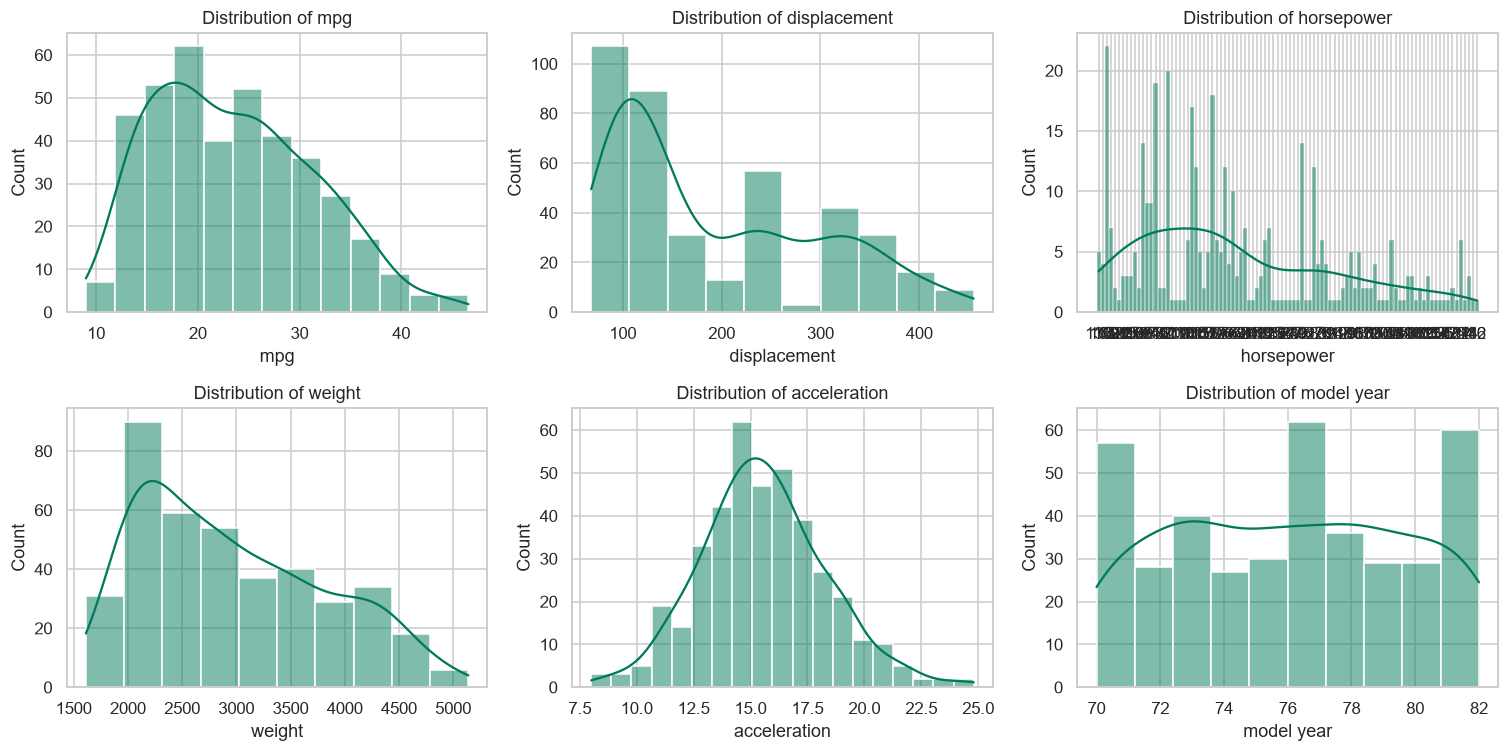

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.histplot(df_clean[c], ax=axes[i], kde=True, color="#007A5B")
    axes[i].set_title(f'Distribution of {c}')
plt.tight_layout()
plt.show()

In [10]:
for i, c in enumerate(['displayment', 'horsepower', 'weight', 'acceleration', 'model year']):
    print(i, c)

0 displayment
1 horsepower
2 weight
3 acceleration
4 model year


skewness - Having a tail skewed distribution

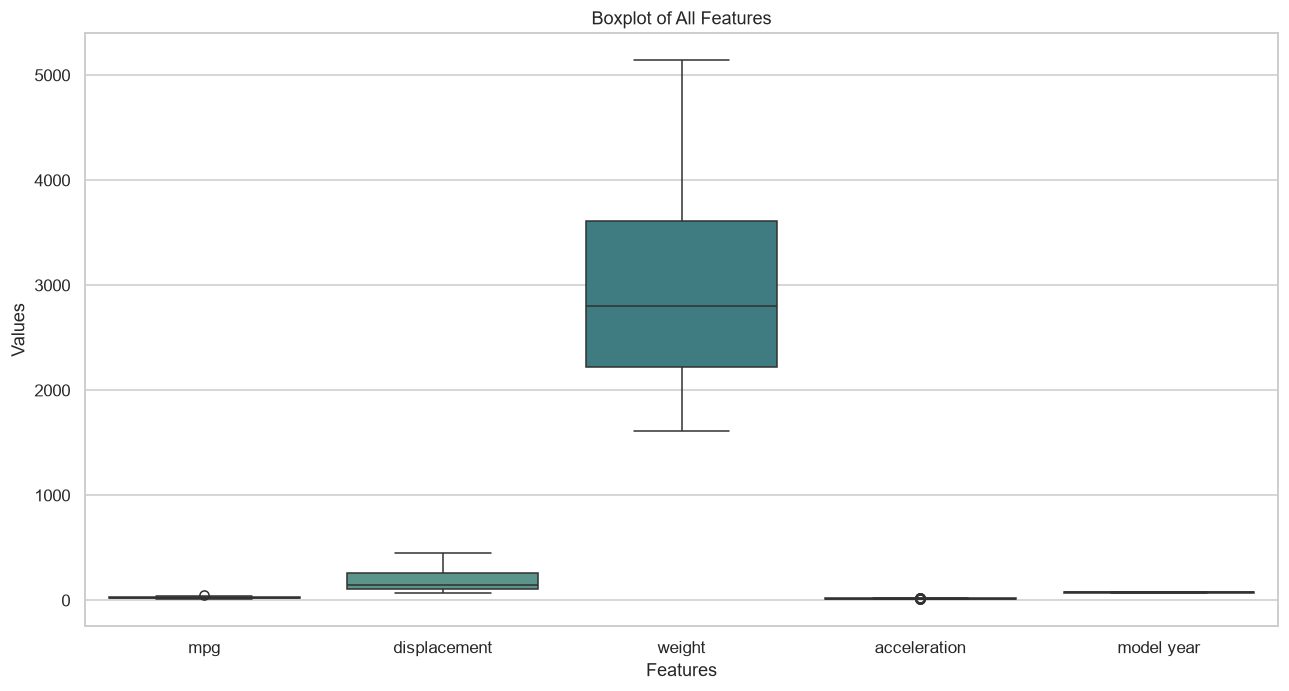

In [11]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean, palette='crest')
plt.title("Boxplot of All Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

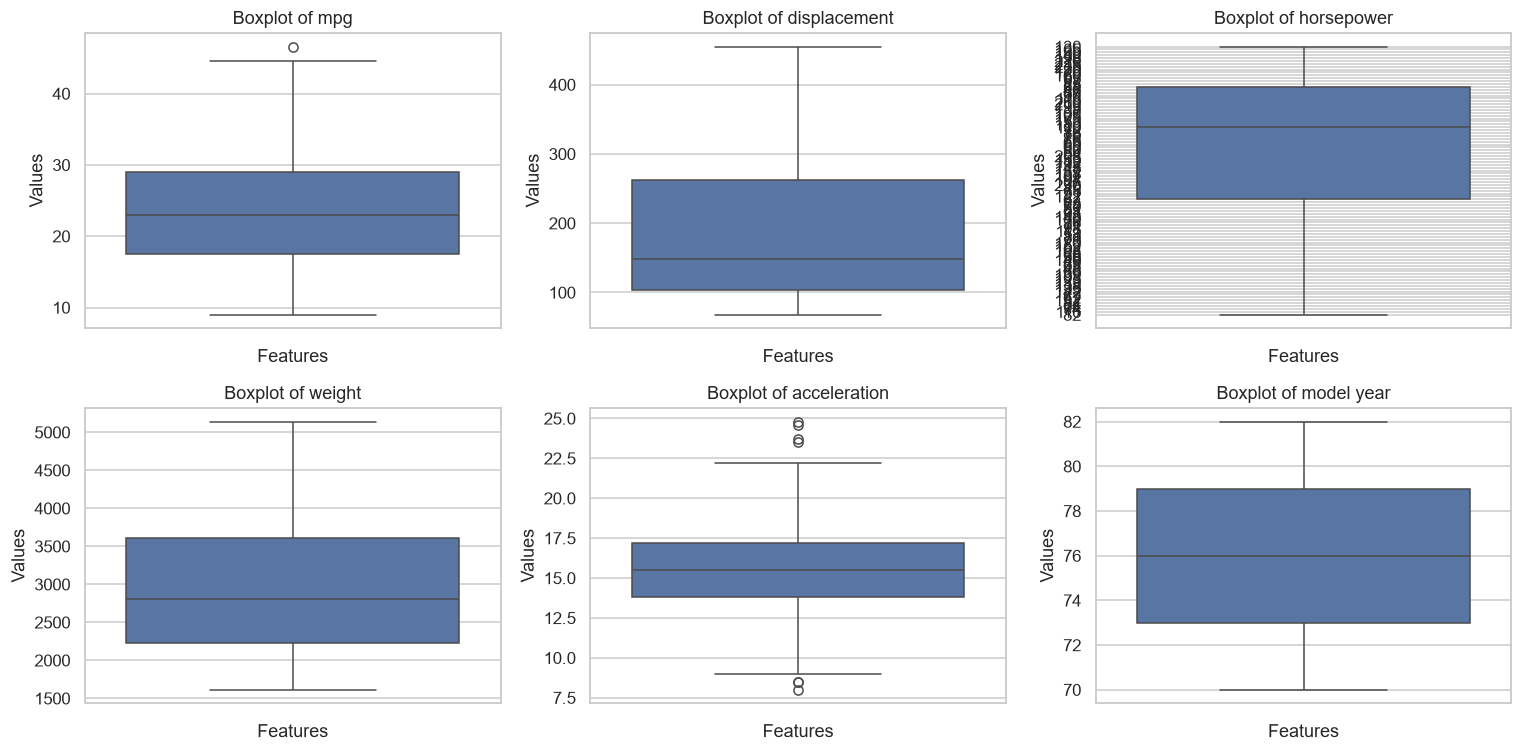

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.boxplot(data=df_clean[c], ax=axes[i])
    axes[i].set_title(f'Boxplot of {c}')
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()

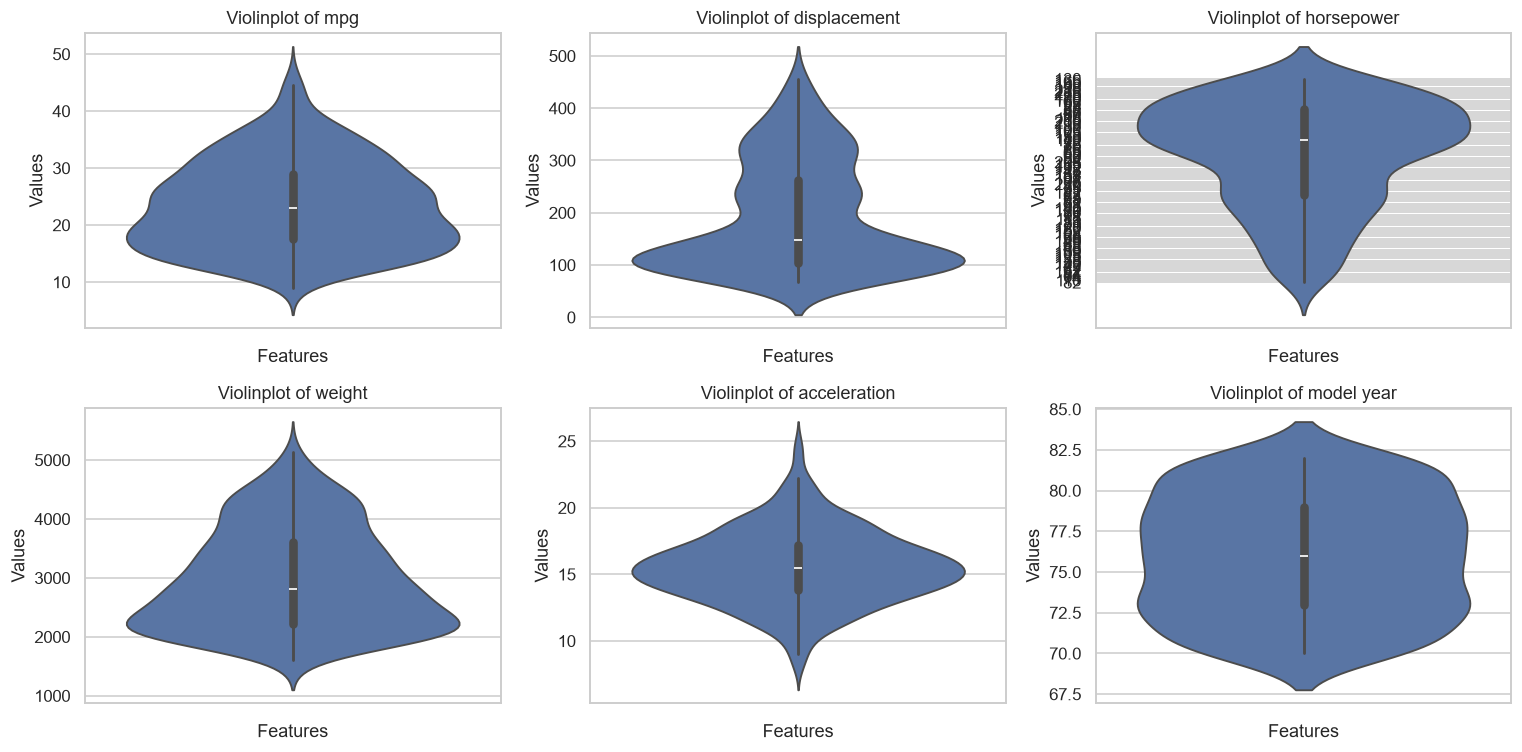

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.violinplot(data=df_clean[c], ax=axes[i])
    axes[i].set_title(f'Violinplot of {c}')
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()

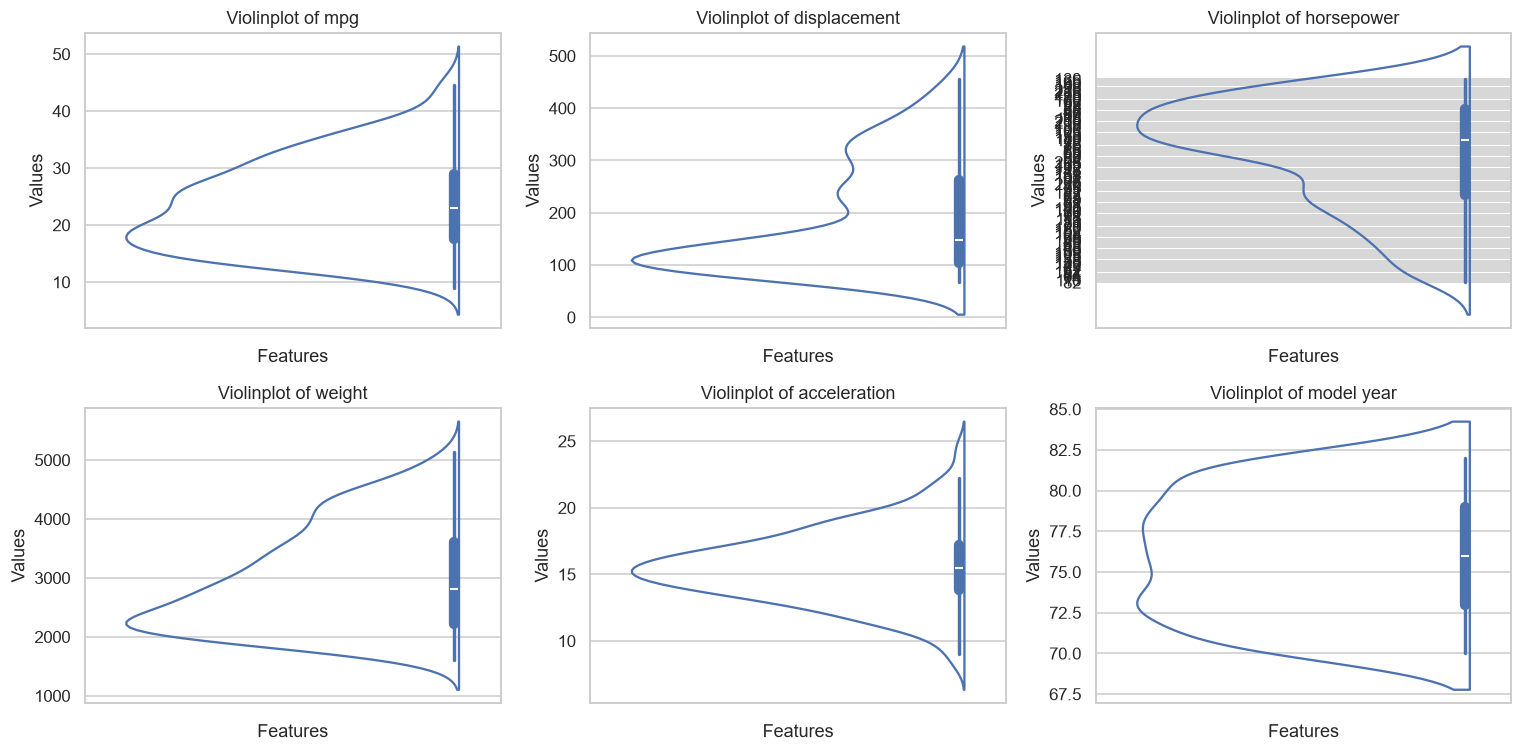

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.violinplot(data=df_clean[c], ax=axes[i], split=True, fill=False)
    axes[i].set_title(f'Violinplot of {c}')
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()

In [15]:
df_clean.dtypes

mpg             float64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
dtype: object

In [16]:
#horsepower eka str type wela thiyenawa. Numeric wenna oona column ekak, namut string wela
df_clean['horsepower'] = pd.to_numeric(df_clean['horsepower'], errors='coerce')

In [17]:
df_clean.skew().sort_values(ascending=False)

horsepower      1.087326
displacement    0.719645
weight          0.531063
mpg             0.457066
acceleration    0.278777
model year      0.011535
dtype: float64

### Bi Variate Analysis

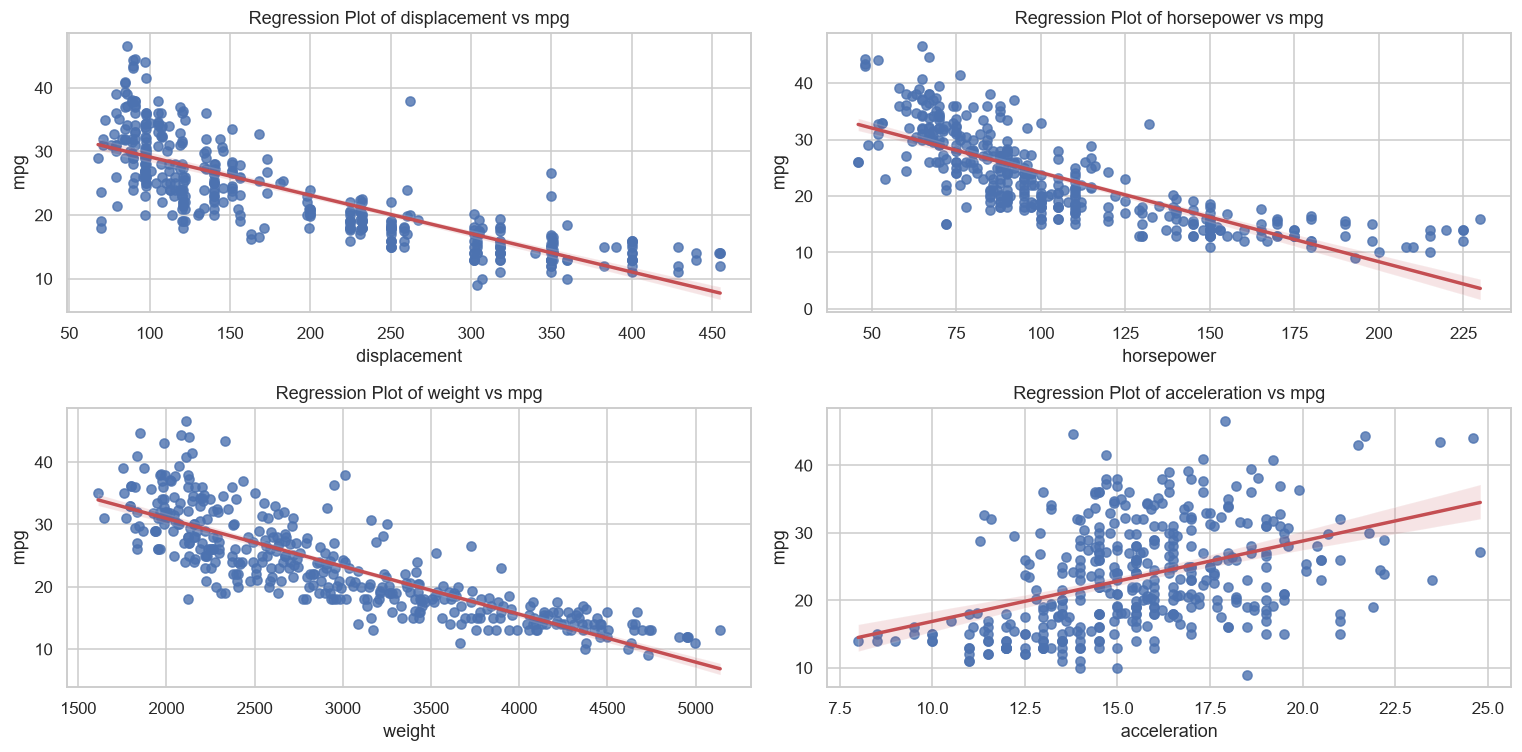

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(quan_candidates[:4]):
    sns.regplot(data=df_clean, x=c, y=TARGET, ax=axes[i], line_kws=dict(color="r"))
    axes[i].set_title(f'Regression Plot of {c} vs {TARGET}')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel(TARGET)

plt.tight_layout()
plt.show()

### Multi Variate Analysis

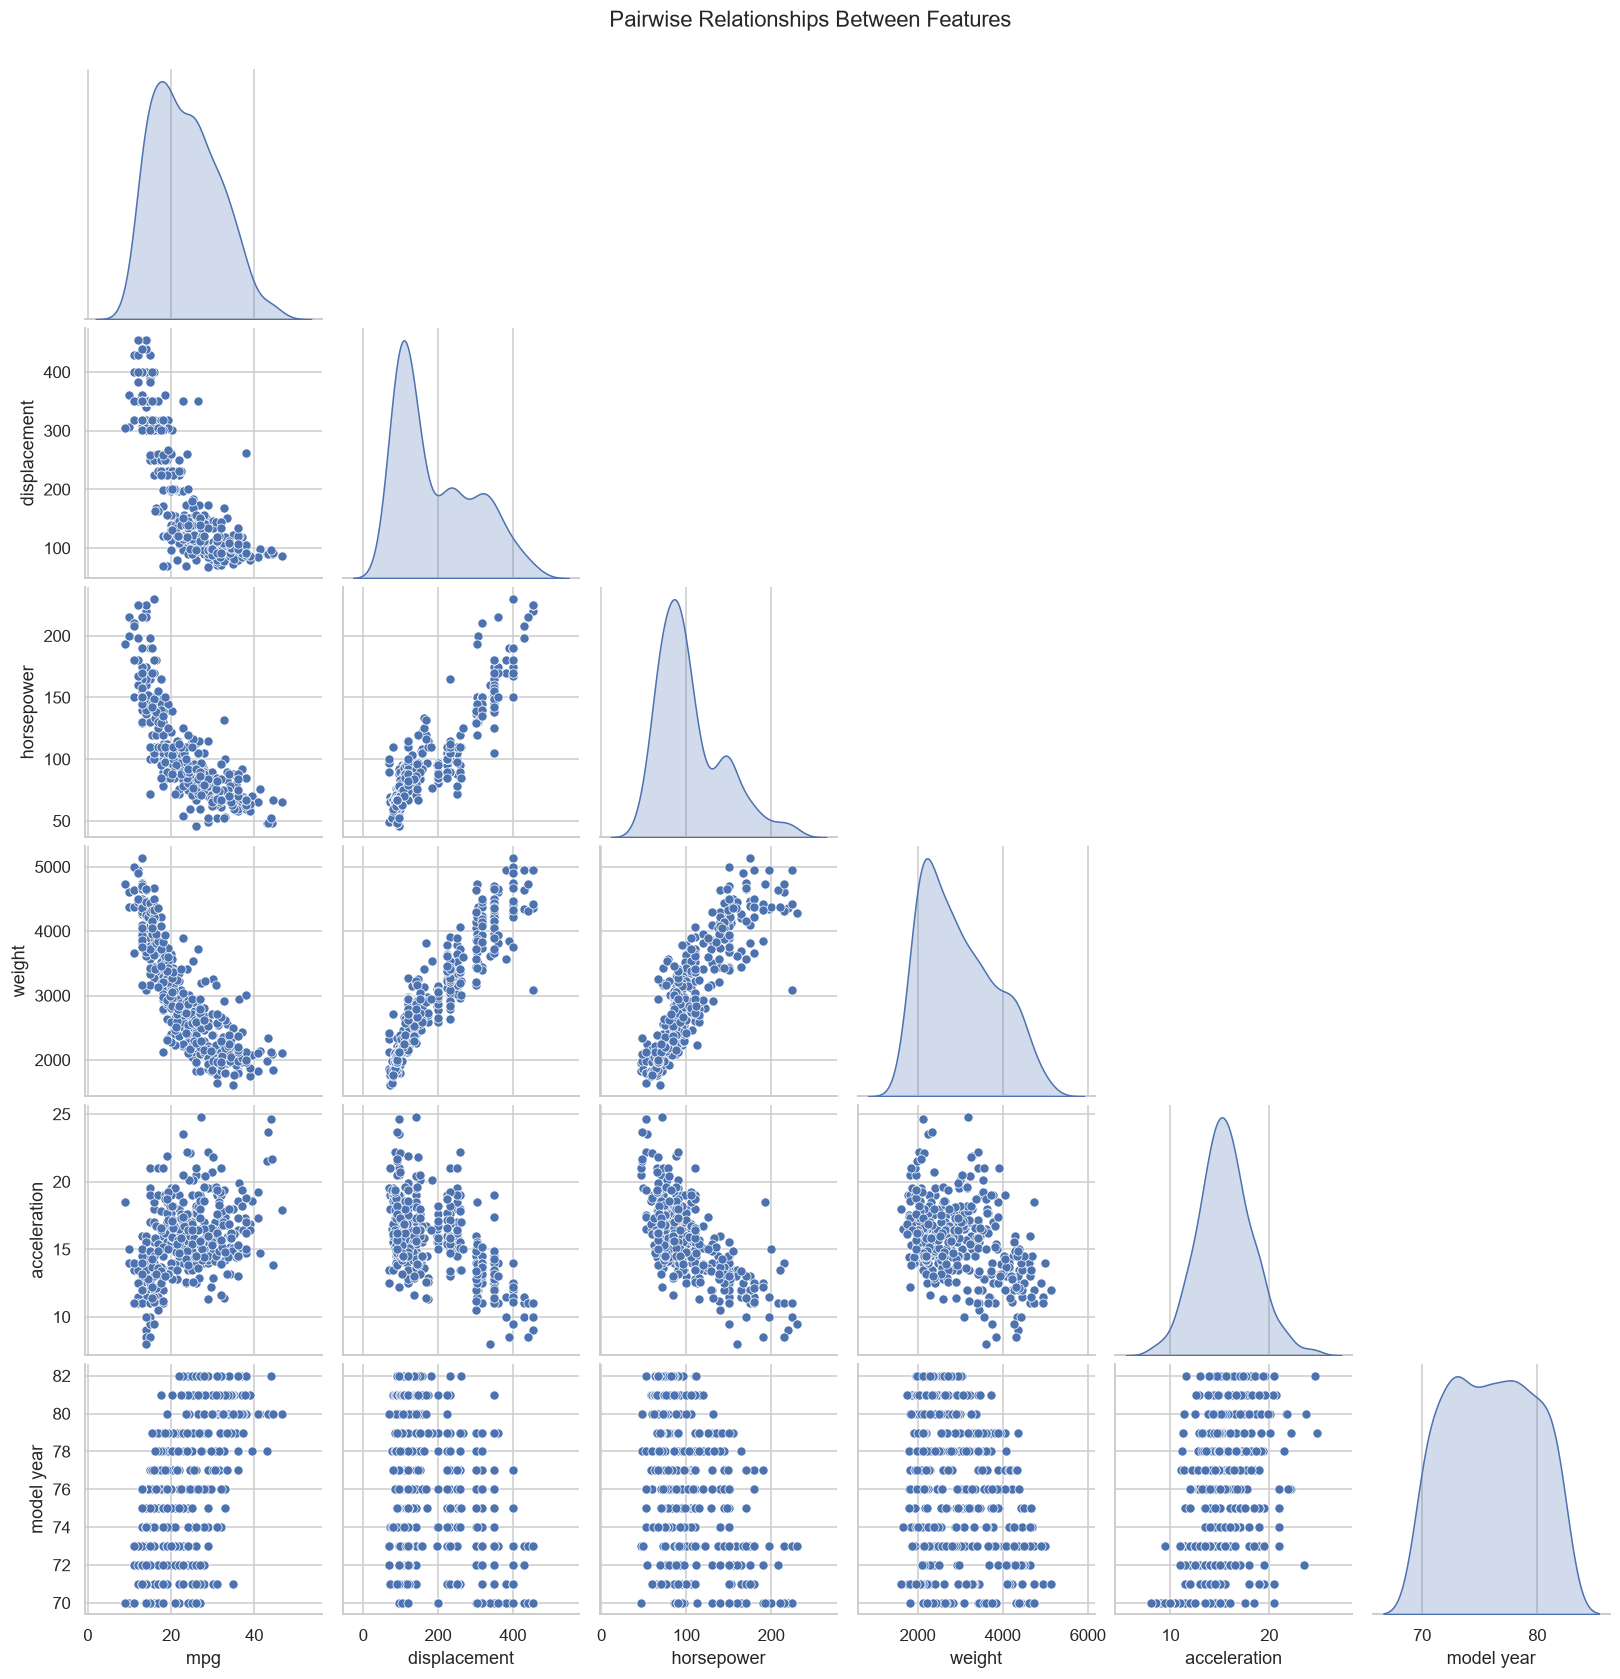

In [19]:
sns.pairplot(df_clean[cols], diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

### Correlation Analysis

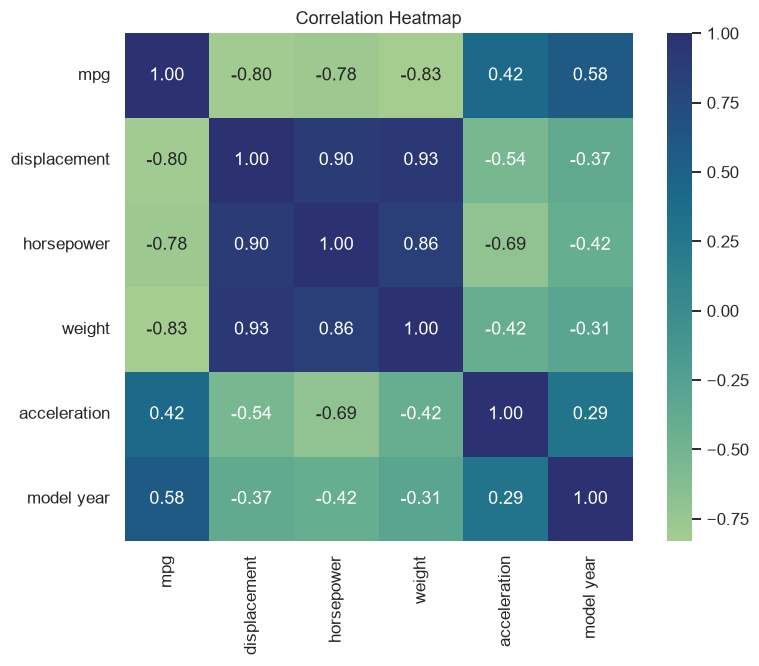

mpg             1.000000
model year      0.579267
acceleration    0.420289
horsepower     -0.778427
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

In [20]:
corr_matrix = df_clean[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="crest", square=True)
plt.title("Correlation Heatmap")
plt.show()

corr_matrix[TARGET].sort_values(ascending=False)

# Model Building - Linear Regression

Now that the data has been explored and understood, we move on to building the predictive model.

1. Prepare the data (handle missing values created by type conversion, define features/target)
2. Split the data into training and test sets
3. Scale the features
4. Train a Linear Regression model
5. Evaluate the model on unseen (test) data
6. Interpret the coefficients
7. Check the residuals (diagnostics)

### 1. Final data preparation

Converting `horsepower` to numeric (done above) turned the 6 originally-missing `?` entries into `NaN`. We drop those rows now, then split the data into features (`X`) and target (`y`).

In [21]:
print("Rows before dropping NaN horsepower:", len(df_clean))
df_model = df_clean.dropna().reset_index(drop=True)
print("Rows after dropping NaN horsepower:", len(df_model))

X = df_model[quan_candidates]
y = df_model[TARGET]

X.head()

Rows before dropping NaN horsepower: 398
Rows after dropping NaN horsepower: 392


,displacement,horsepower,weight,acceleration,model year
0,307.0,130.0,3504,12.0,70
1,350.0,165.0,3693,11.5,70
2,318.0,150.0,3436,11.0,70
3,304.0,150.0,3433,12.0,70
4,302.0,140.0,3449,10.5,70


### 2. Train / Test Split

We hold out 20% of the data as an unseen test set so the model's performance can be judged honestly.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (313, 5)
Test set size: (79, 5)


### 3. Feature Scaling

Linear Regression doesn't strictly require scaling, but standardizing the features (mean = 0, std = 1) makes the resulting coefficients directly comparable to one another. The scaler is **fit only on the training data** and then used to transform both sets, to avoid leaking information from the test set.

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]

,mean,std
displacement,3.972683e-17,1.001601
horsepower,-1.475568e-16,1.001601
weight,2.553868e-16,1.001601
acceleration,5.646885e-16,1.001601
model year,-1.801896e-15,1.001601


### 4. Train the Linear Regression Model

In [24]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_table = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Intercept:", model.intercept_)
coef_table

Intercept: 23.599361022364224


,feature,coefficient
2,weight,-5.527638
4,model year,2.757645
3,acceleration,0.175688
1,horsepower,-0.075446
0,displacement,-0.075355


### 5. Predict and Evaluate

We predict on both the training set (to check for underfitting) and the test set (to check generalization), using RMSE, MAE and R² as evaluation metrics.

In [25]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

metrics = pd.DataFrame({
    'RMSE': [rmse(y_train, y_train_pred), rmse(y_test, y_test_pred)],
    'MAE': [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
    'R2': [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)],
}, index=['train', 'test'])

metrics

,RMSE,MAE,R2
train,3.456428,2.667519,0.810667
test,3.252488,2.513256,0.792740


### 6. Actual vs Predicted

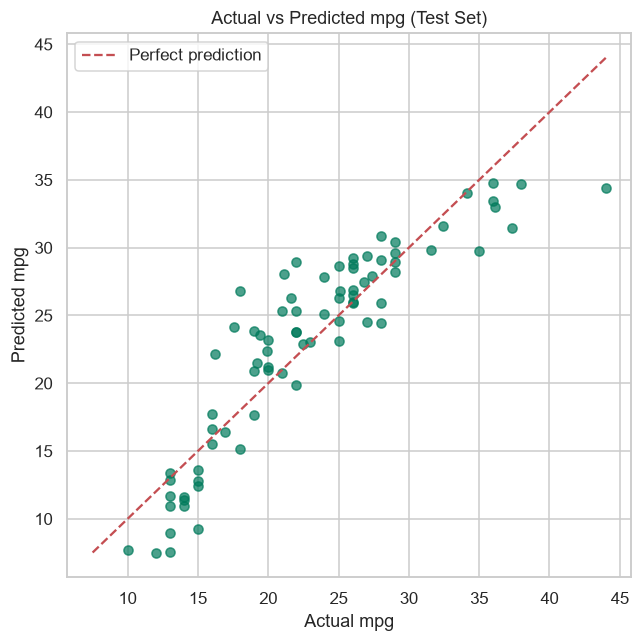

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, color="#007A5B")
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual mpg')
plt.ylabel('Predicted mpg')
plt.title('Actual vs Predicted mpg (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

### 7. Residual Diagnostics

The residual plot checks for patterns (there shouldn't be any obvious ones, if the linear model is a good fit), and the histogram checks that residuals are roughly normally distributed around zero.

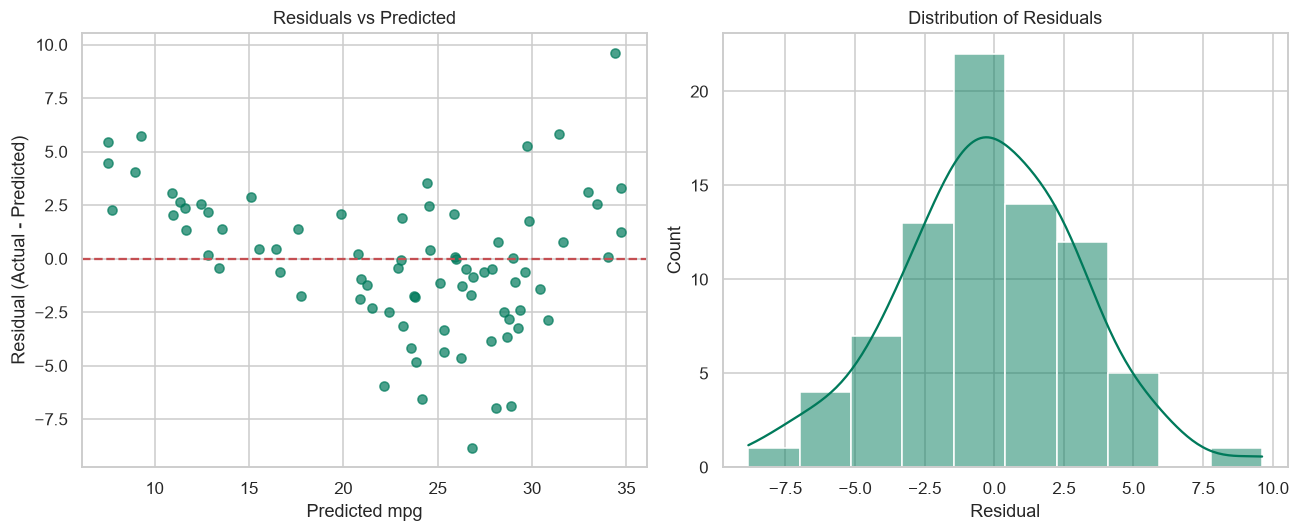

In [27]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_pred, residuals, alpha=0.7, color="#007A5B")
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted mpg')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[1], color="#007A5B")
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

# Conclusion

- The dataset (`auto-mpg.csv`) was cleaned by dropping non-numeric/identifier columns (`origin`, `car name`, `cylinders`) and rows with missing values, and by converting `horsepower` from text to numeric.
- EDA showed that `mpg` is right-skewed, `weight`/`displacement`/`horsepower` are strongly correlated with each other (multicollinearity) and negatively correlated with `mpg`, while `model year` is positively correlated with `mpg`.
- A Linear Regression model was trained on standardized features (`displacement`, `horsepower`, `weight`, `acceleration`, `model year`) to predict `mpg`, using an 80/20 train/test split.
- The model's test-set R², RMSE and MAE (see the metrics table above) show how well it generalizes to unseen cars, and the residual plots confirm whether the linear assumption is reasonable.
- `weight` and `model year` are the strongest drivers of predicted `mpg` (see the coefficient table above).